# Régression — Estimer la position d’arrivée (F1)

> Objectif : définir une **position attendue** (finish) et comparer la performance réelle vs attendue.

Ce notebook :
- charge le dataset nettoyé `prepared_data.csv` (on ne *re-nettoie* pas le dataset) ;
- choisit une colonne cible (par défaut `positionOrder`) ;
- entraîne 5 modèles de régression **un par un** avec **Grid Search** puis **Random Search** ;
- affiche, pour chaque modèle et méthode, les **meilleurs hyperparamètres** + quelques **graphiques** (prédiction vs réel, résidus) ;
- termine par une **comparaison globale** des modèles.

---


In [1]:
# Imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

In [2]:
# Chargement + inspection rapide du dataset
DATA_PATH = "prepared_data.csv"
df = pd.read_csv(DATA_PATH)

display(df.head())
print("Shape:", df.shape)
print("Colonnes:", len(df.columns))

# Valeurs manquantes (aperçu)
na = df.isna().mean().sort_values(ascending=False)
display(na.head(15))

# Statistiques rapides sur les colonnes numériques
display(df.describe(include=[np.number]).T.head(20))

,year,round,grid,qualifying_position,driver_standing_pos,driver_points_cum,driver_wins_cum,constructor_standing_pos,constructor_points_cum,constructor_wins_cum,country,podium,position_class,finish_pos_penalty,country_encoded,position_class_encoded
0,2008,1,1,1.0,1.0,10.0,1.0,1.0,14.0,1.0,Australia,1,0,1,1,0
1,2008,1,5,5.0,2.0,8.0,0.0,3.0,8.0,0.0,Australia,1,1,2,1,1
2,2008,1,7,7.0,3.0,6.0,0.0,2.0,9.0,0.0,Australia,1,1,3,1,1
3,2008,1,11,12.0,4.0,5.0,0.0,4.0,5.0,0.0,Australia,0,2,4,1,2
4,2008,1,3,3.0,5.0,4.0,0.0,1.0,14.0,1.0,Australia,0,2,5,1,2


Shape: (26487, 16)
Colonnes: 16


qualifying_position         0.613622
constructor_standing_pos    0.070034
constructor_wins_cum        0.070034
constructor_points_cum      0.070034
driver_wins_cum             0.017254
driver_points_cum           0.017254
driver_standing_pos         0.017254
grid                        0.000000
round                       0.000000
year                        0.000000
country                     0.000000
podium                      0.000000
position_class              0.000000
finish_pos_penalty          0.000000
country_encoded             0.000000
dtype: float64

,count,mean,std,min,25%,50%,75%,max
year,26487.0,1991.073734,19.790507,1950.0,1977.0,1991.0,2008.0,2024.0
round,26487.0,8.419074,4.993374,1.0,4.0,8.0,12.0,22.0
grid,26487.0,11.152112,7.212024,0.0,5.0,11.0,17.0,34.0
qualifying_position,10234.0,11.213504,6.271415,1.0,6.0,11.0,16.0,28.0
driver_standing_pos,26030.0,14.561544,10.912575,1.0,7.0,13.0,20.0,105.0
driver_points_cum,26030.0,18.336421,41.848072,0.0,0.0,3.0,16.0,575.0
driver_wins_cum,26030.0,0.354091,1.159515,0.0,0.0,0.0,0.0,19.0
constructor_standing_pos,24632.0,6.461026,3.980253,1.0,3.0,6.0,9.0,21.0
constructor_points_cum,24632.0,39.138580,82.685999,0.0,1.0,10.0,36.0,860.0
constructor_wins_cum,24632.0,0.788487,1.950881,0.0,0.0,0.0,1.0,21.0


Cible choisie (TARGET_COL) : finish_pos_penalty


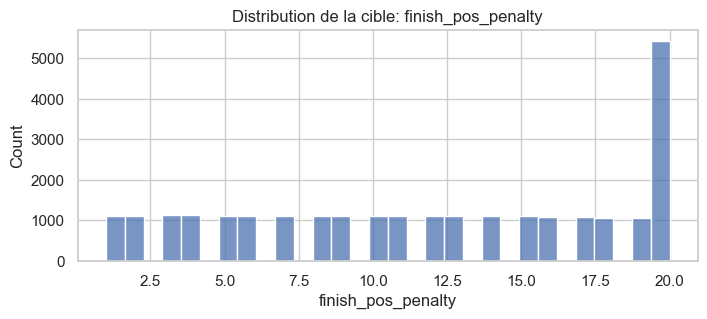

In [3]:
# Définition de la cible (colonne à prédire)

# On essaye de deviner automatiquement la colonne cible la plus plausible.
# Vous pouvez forcer le choix en modifiant TARGET_COL ci-dessous.
candidate_targets = [
    "finish_pos_penalty",     # position d'arrivée (souvent 1..N)
    "positionOrder",          # position d'arrivée (souvent 1..N)
    "qualifying_position",    # position en qualif (si l’objectif change)
    "driver_standing_pos",    # position au classement (si l’objectif change)
    "constructor_standing_pos"
 ]

found_candidates = [c for c in candidate_targets if c in df.columns]
if len(found_candidates) == 0:
    raise ValueError(
        "Impossible de détecter une colonne cible automatiquement. "
        "Choisissez une colonne cible parmi: \n" + "\n".join(df.columns)
    )

# Par défaut : position d'arrivée
TARGET_COL = found_candidates[0]
print("Cible choisie (TARGET_COL) :", TARGET_COL)

# Petite distribution de la cible
plt.figure(figsize=(8, 3))
sns.histplot(df[TARGET_COL], bins=30, kde=False)
plt.title(f"Distribution de la cible: {TARGET_COL}")
plt.show()

In [4]:
# Préparation des features (sans "nettoyer" le dataset : on se limite à définir X/y)

# IMPORTANT (anti-fuite de cible) : certaines colonnes sont directement dérivées du résultat.
# Les garder rendrait le modèle artificiellement trop bon (target leakage).
# Ajustez cette liste si besoin selon votre objectif.
LEAKAGE_COLS = [
    "points",                  # points attribués selon la position
    "podium",                  # dérivé (top 3)
    "is_top3",                 # dérivé (top 3)
    "position_class",          # catégorie dérivée de la position
    "positionOrder",           # si calculée à partir du finish
    "result_category_podium",  # dérivé
    "result_category_points",  # dérivé
    "result_category_win"      # dérivé
 ]
LEAKAGE_COLS = [c for c in LEAKAGE_COLS if c in df.columns and c != TARGET_COL]

y = df[TARGET_COL].astype(float)
X = df.drop(columns=[TARGET_COL] + LEAKAGE_COLS)

print("X shape:", X.shape, "| y shape:", y.shape)
print("Colonnes retirées (fuite de cible):", LEAKAGE_COLS)

# Split train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
 )

# Colonnes numériques / catégorielles
num_cols = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
print("Num cols:", len(num_cols), "| Cat cols:", len(cat_cols))

# Prétraitement: imputation + scaling (utile pour KNN & SVR) + OneHot si nécessaire
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Compatibilité scikit-learn: 'sparse_output' (>=1.2) vs 'sparse' (<1.2)
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
 )

# Validation croisée
# (3 folds = plus rapide; passez à 5 ou 10 si vous avez plus de temps)
cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

X shape: (26487, 13) | y shape: (26487,)
Colonnes retirées (fuite de cible): ['podium', 'position_class']
Num cols: 12 | Cat cols: 1


In [5]:
# Fonctions réutilisables : Grid Search / Random Search + évaluation

def regression_metrics(y_true, y_pred):
    """Calcule quelques métriques de régression."""
    mae = mean_absolute_error(y_true, y_pred)

    # Compatibilité scikit-learn: certains environnements n'acceptent plus squared=False
    try:
        rmse = mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    r2 = r2_score(y_true, y_pred)
    return {"MAE": float(mae), "RMSE": float(rmse), "R2": float(r2)}


def plot_diagnostics(y_true, y_pred, title_prefix=""):
    """Graphiques simples : prédiction vs réel + résidus."""
    residuals = y_true - y_pred

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # Pred vs True
    axes[0].scatter(y_true, y_pred, alpha=0.35)
    minv = min(np.min(y_true), np.min(y_pred))
    maxv = max(np.max(y_true), np.max(y_pred))
    axes[0].plot([minv, maxv], [minv, maxv], "r--", linewidth=2)
    axes[0].set_title(f"{title_prefix}Prédiction vs Réel")
    axes[0].set_xlabel("Réel")
    axes[0].set_ylabel("Prédit")

    # Residuals
    sns.histplot(residuals, bins=30, kde=True, ax=axes[1])
    axes[1].set_title(f"{title_prefix}Distribution des résidus (réel - prédit)")
    axes[1].set_xlabel("Résidu")

    plt.tight_layout()
    plt.show()


def grid_search_classif(pipeline, param_grid, X_train, y_train, cv, scoring="neg_mean_absolute_error", n_jobs=-1, verbose=0):
    """GridSearchCV (nom conservé comme demandé, mais utilisé ici pour de la régression)."""
    gs = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=n_jobs,
        verbose=verbose,
        refit=True,
        return_train_score=True,
    )
    gs.fit(X_train, y_train)
    return gs


def random_search_classif(pipeline, param_distributions, X_train, y_train, cv, scoring="neg_mean_absolute_error", n_jobs=-1, n_iter=25, verbose=0):
    """RandomizedSearchCV (nom conservé comme demandé, mais utilisé ici pour de la régression)."""
    rs = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        scoring=scoring,
        cv=cv,
        n_jobs=n_jobs,
        n_iter=n_iter,
        random_state=RANDOM_STATE,
        verbose=verbose,
        refit=True,
        return_train_score=True,
    )
    rs.fit(X_train, y_train)
    return rs


def run_search_and_evaluate(model_name, search_name, search_obj, X_test, y_test):
    """Affiche meilleurs paramètres + métriques test + graphiques."""
    print(f"\n[{model_name}] {search_name}")
    print("Meilleurs hyperparamètres :")
    display(pd.Series(search_obj.best_params_).sort_index())

    best_model = search_obj.best_estimator_
    y_pred = best_model.predict(X_test)
    metrics = regression_metrics(y_test, y_pred)
    print("Métriques (test) :", metrics)

    plot_diagnostics(y_test, y_pred, title_prefix=f"{model_name} - {search_name} | ")
    return metrics

In [6]:
# Stockage des résultats (résumé final)

# On initialise results seulement si la variable n'existe pas (pratique quand on ré-exécute des cellules).
try:
    results
except NameError:
    results = []

def add_result(model_name, search_method, search_obj, test_metrics):
    """Stocke un résumé (facile à convertir en DataFrame à la fin).

    Remarque : si on ré-exécute une section (par ex. RandomForest),
    on remplace l'entrée existante (modèle, méthode) pour éviter les doublons.
    """
    global results
    results = [r for r in results if not (r["modele"] == model_name and r["methode"] == search_method)]

    results.append({
        "modele": model_name,
        "methode": search_method,
        "best_params": search_obj.best_params_,
        "cv_best_score_neg_mae": search_obj.best_score_,
        "test_mae": test_metrics["MAE"],
        "test_rmse": test_metrics["RMSE"],
        "test_r2": test_metrics["R2"],
        "fit_time_sec": getattr(search_obj, "refit_time_", np.nan),
    })

In [7]:
def make_pipeline(model):
    """Construit un pipeline preprocess + modèle."""
    return Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model),
    ])

## 1) KNN (K-Nearest Neighbors) — Régression
On teste un modèle KNN pour estimer la position d’arrivée.


[KNN] Grid Search
Meilleurs hyperparamètres :


model__n_neighbors           7
model__p                     2
model__weights        distance
dtype: object

Métriques (test) : {'MAE': 2.003053457364618, 'RMSE': 2.660841903412534, 'R2': 0.8226140651777297}


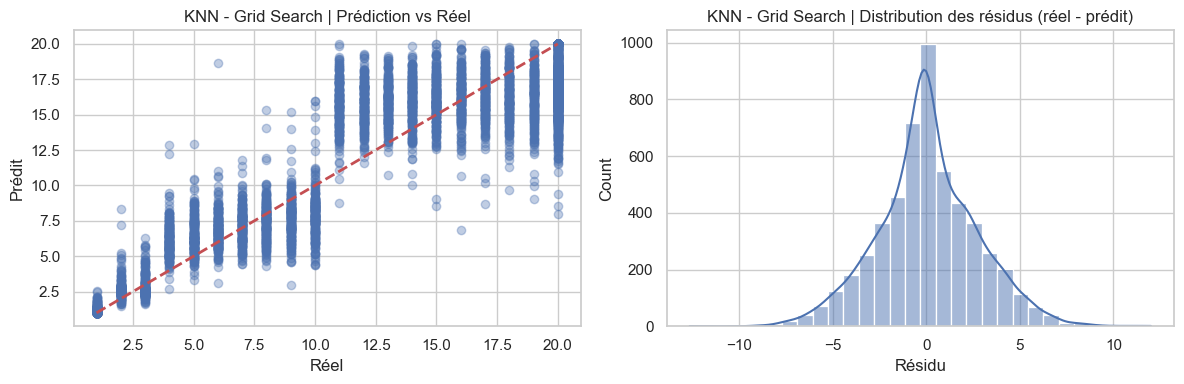


[KNN] Random Search
Meilleurs hyperparamètres :


model__leaf_size            30
model__n_neighbors          13
model__p                     2
model__weights        distance
dtype: object

Métriques (test) : {'MAE': 2.0064251657142904, 'RMSE': 2.629692656550873, 'R2': 0.8267429060456932}


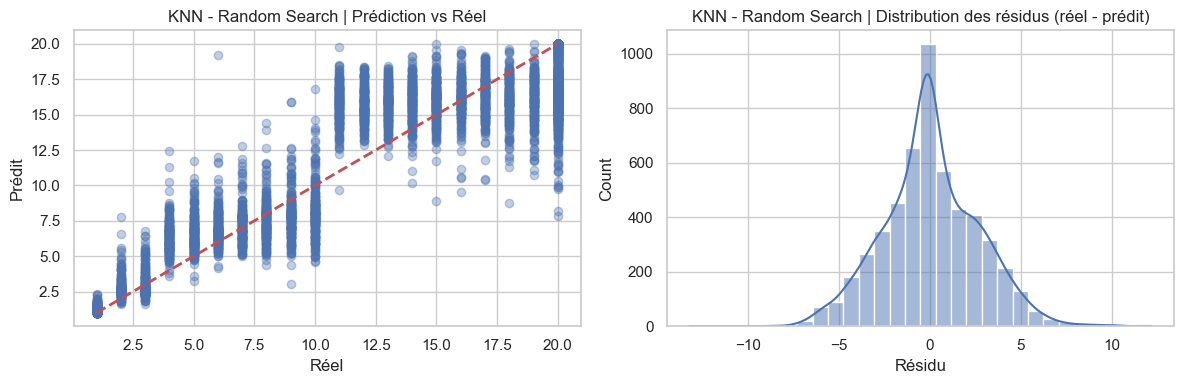

In [8]:
model_name = "KNN"
knn = KNeighborsRegressor()
pipe_knn = make_pipeline(knn)

# Grille Grid Search
param_grid_knn = {
    "model__n_neighbors": [3, 5, 7, 9, 15, 25],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],  # 1=Manhattan, 2=Euclidien
}

gs_knn = grid_search_classif(pipe_knn, param_grid_knn, X_train, y_train, cv=cv, verbose=0)
metrics_gs = run_search_and_evaluate(model_name, "Grid Search", gs_knn, X_test, y_test)
add_result(model_name, "Grid", gs_knn, metrics_gs)

# Distributions Random Search (listes = choix aléatoires)
param_dist_knn = {
    "model__n_neighbors": list(range(2, 51)),
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],
    "model__leaf_size": [10, 20, 30, 40, 50],
}

rs_knn = random_search_classif(pipe_knn, param_dist_knn, X_train, y_train, cv=cv, n_iter=25, verbose=0)
metrics_rs = run_search_and_evaluate(model_name, "Random Search", rs_knn, X_test, y_test)
add_result(model_name, "Random", rs_knn, metrics_rs)

## 2) SVM (SVR) — Régression
SVM en version régression (SVR). Souvent performant mais plus coûteux en temps.


[SVR] Grid Search
Meilleurs hyperparamètres :


model__C             10
model__epsilon     0.05
model__gamma      scale
model__kernel       rbf
dtype: object

Métriques (test) : {'MAE': 1.8354068454479389, 'RMSE': 2.436276217339764, 'R2': 0.851292083163762}


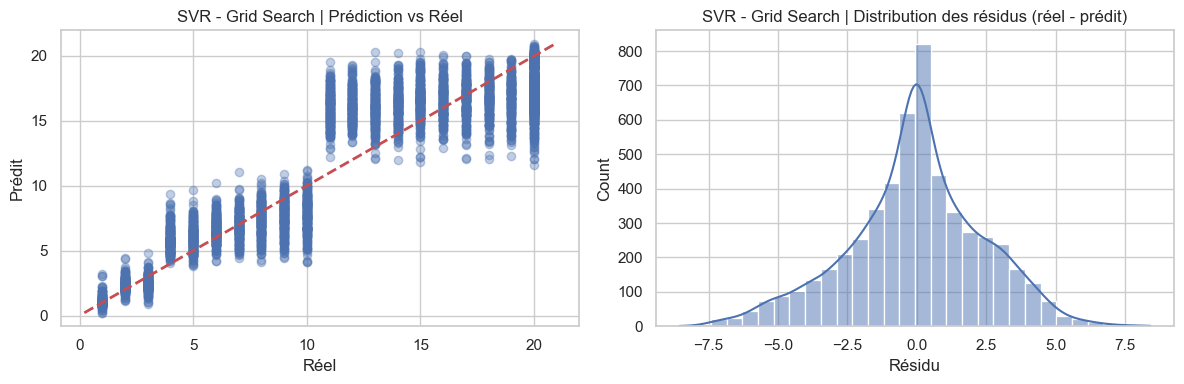


[SVR] Random Search
Meilleurs hyperparamètres :


model__C           10.0
model__degree         3
model__epsilon    0.505
model__gamma      scale
model__kernel       rbf
dtype: object

Métriques (test) : {'MAE': 1.8523678366904532, 'RMSE': 2.433565534612068, 'R2': 0.8516228139138179}


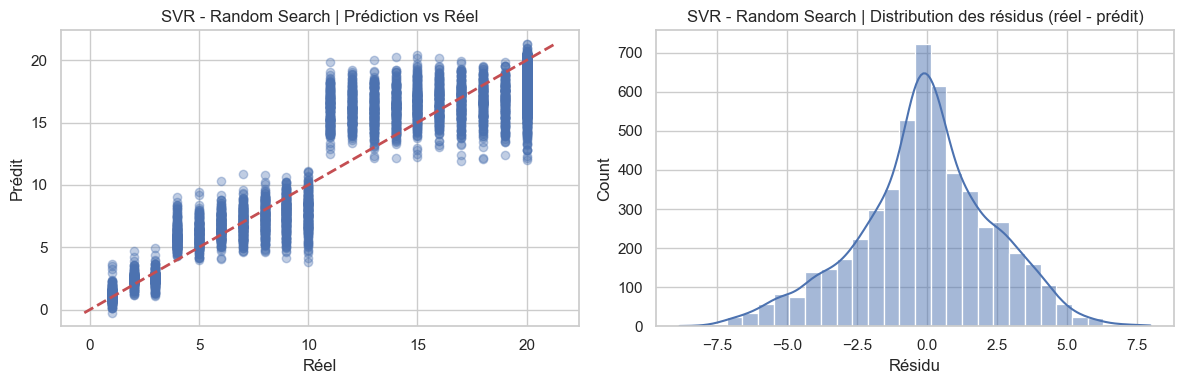

In [9]:
model_name = "SVR"
svr = SVR()
pipe_svr = make_pipeline(svr)

# Grid Search (grille réduite pour un temps de calcul raisonnable)
param_grid_svr = {
    "model__kernel": ["rbf", "linear"],
    "model__C": [0.1, 1, 10],
    "model__epsilon": [0.05, 0.2, 0.6],
    "model__gamma": ["scale", "auto"],
}

gs_svr = grid_search_classif(pipe_svr, param_grid_svr, X_train, y_train, cv=cv, verbose=0)
metrics_gs = run_search_and_evaluate(model_name, "Grid Search", gs_svr, X_test, y_test)
add_result(model_name, "Grid", gs_svr, metrics_gs)

# Random Search
param_dist_svr = {
    "model__kernel": ["rbf", "linear", "poly"],
    "model__C": np.logspace(-2, 2, 25).tolist(),
    "model__epsilon": np.linspace(0.01, 1.0, 25).tolist(),
    "model__gamma": ["scale", "auto"],
    "model__degree": [2, 3, 4],  # utile si kernel='poly'
}

rs_svr = random_search_classif(pipe_svr, param_dist_svr, X_train, y_train, cv=cv, n_iter=25, verbose=0)
metrics_rs = run_search_and_evaluate(model_name, "Random Search", rs_svr, X_test, y_test)
add_result(model_name, "Random", rs_svr, metrics_rs)

## 3) Decision Tree — Régression
Arbre de décision (simple) : rapide et interprétable, mais peut sur-apprendre sans régularisation.


[DecisionTree] Grid Search
Meilleurs hyperparamètres :


model__max_depth            12.0
model__max_features          NaN
model__min_samples_leaf      8.0
model__min_samples_split    20.0
dtype: float64

Métriques (test) : {'MAE': 1.7488465556469854, 'RMSE': 2.3703551042014688, 'R2': 0.8592307281860568}


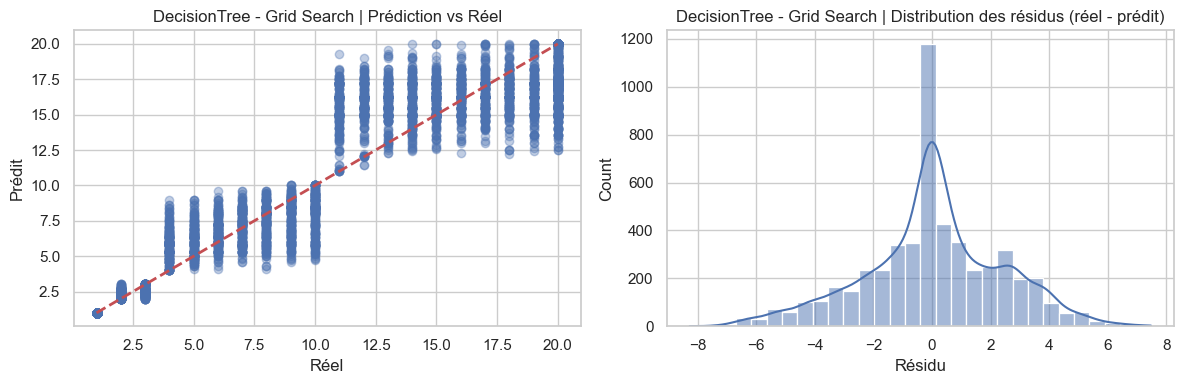


[DecisionTree] Random Search
Meilleurs hyperparamètres :


model__max_depth            10.0
model__max_features          NaN
model__min_samples_leaf      5.0
model__min_samples_split    21.0
dtype: float64

Métriques (test) : {'MAE': 1.7369749274814188, 'RMSE': 2.334182410081336, 'R2': 0.8634943515207208}


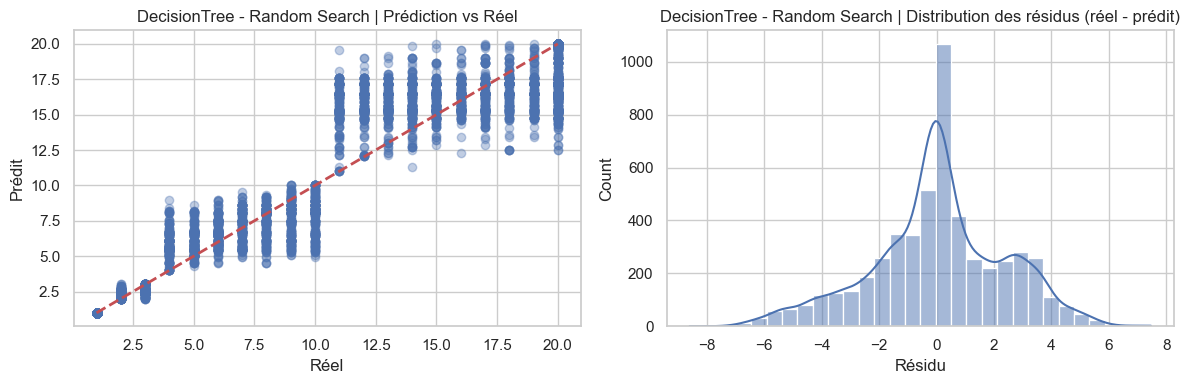

In [10]:
model_name = "DecisionTree"
dt = DecisionTreeRegressor(random_state=RANDOM_STATE)
pipe_dt = make_pipeline(dt)

param_grid_dt = {
    "model__max_depth": [None, 3, 5, 8, 12, 20],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": [None, "sqrt", "log2"],
}

gs_dt = grid_search_classif(pipe_dt, param_grid_dt, X_train, y_train, cv=cv, verbose=0)
metrics_gs = run_search_and_evaluate(model_name, "Grid Search", gs_dt, X_test, y_test)
add_result(model_name, "Grid", gs_dt, metrics_gs)

param_dist_dt = {
    "model__max_depth": [None] + list(range(2, 31)),
    "model__min_samples_split": list(range(2, 31)),
    "model__min_samples_leaf": list(range(1, 21)),
    "model__max_features": [None, "sqrt", "log2"],
}

rs_dt = random_search_classif(pipe_dt, param_dist_dt, X_train, y_train, cv=cv, n_iter=35, verbose=0)
metrics_rs = run_search_and_evaluate(model_name, "Random Search", rs_dt, X_test, y_test)
add_result(model_name, "Random", rs_dt, metrics_rs)

## 4) Random Forest — Régression
Ensemble d’arbres : généralement robuste, bon compromis précision / interprétabilité.


[RandomForest] Grid Search
Meilleurs hyperparamètres :


model__max_depth            None
model__max_features         sqrt
model__min_samples_leaf        1
model__min_samples_split       2
model__n_estimators          400
dtype: object

Métriques (test) : {'MAE': 1.873452718006795, 'RMSE': 2.4145108525121253, 'R2': 0.8539372873472115}


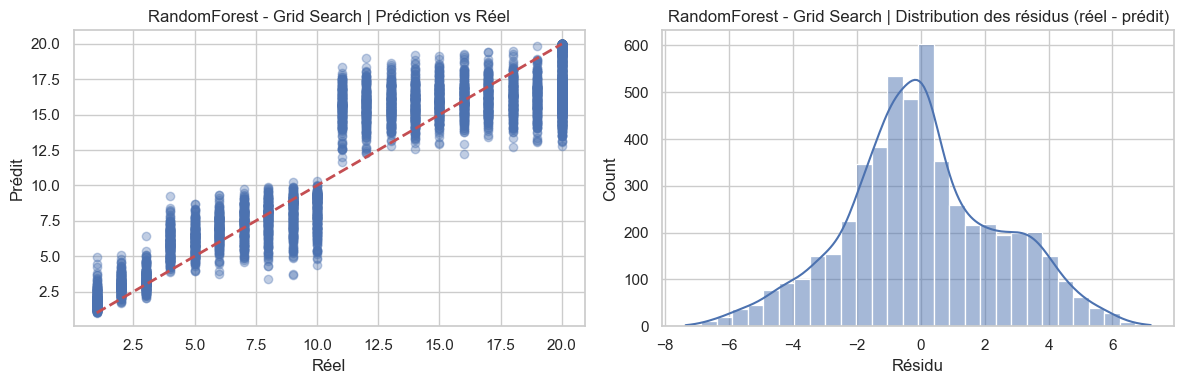


[RandomForest] Random Search
Meilleurs hyperparamètres :


model__bootstrap            False
model__max_depth               20
model__max_features          sqrt
model__min_samples_leaf         1
model__min_samples_split        9
model__n_estimators           800
dtype: object

Métriques (test) : {'MAE': 1.8747708474597602, 'RMSE': 2.3833505851475323, 'R2': 0.8576829608198612}


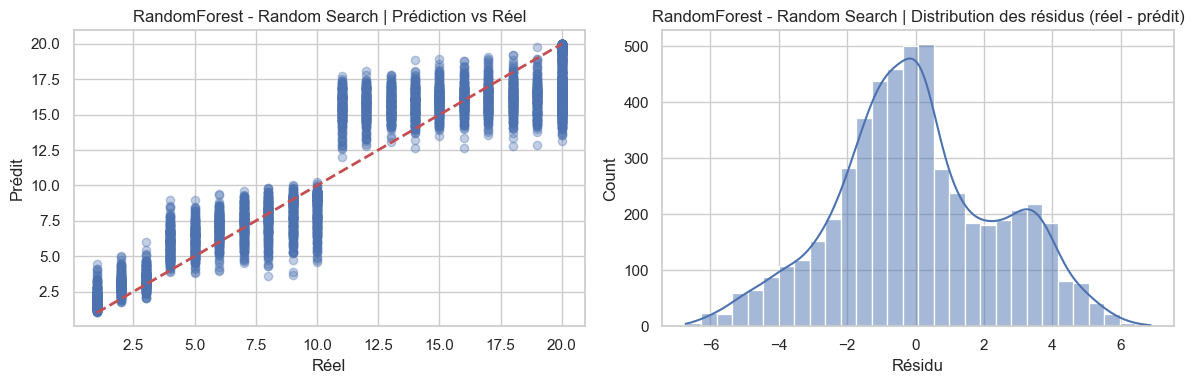

In [11]:
model_name = "RandomForest"
rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
pipe_rf = make_pipeline(rf)

param_grid_rf = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 8, 12, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}

gs_rf = grid_search_classif(pipe_rf, param_grid_rf, X_train, y_train, cv=cv, verbose=0)
metrics_gs = run_search_and_evaluate(model_name, "Grid Search", gs_rf, X_test, y_test)
add_result(model_name, "Grid", gs_rf, metrics_gs)

param_dist_rf = {
    "model__n_estimators": [200, 300, 400, 600, 800],
    "model__max_depth": [None] + list(range(5, 31, 5)),
    "model__min_samples_split": list(range(2, 21)),
    "model__min_samples_leaf": list(range(1, 11)),
    "model__max_features": ["sqrt", "log2"],
    "model__bootstrap": [True, False],
}

rs_rf = random_search_classif(pipe_rf, param_dist_rf, X_train, y_train, cv=cv, n_iter=35, verbose=0)
metrics_rs = run_search_and_evaluate(model_name, "Random Search", rs_rf, X_test, y_test)
add_result(model_name, "Random", rs_rf, metrics_rs)

## 5) XGBoost — Régression
Boosting de gradient (souvent très performant). On utilise `XGBRegressor`.

In [12]:
# Installation/import XGBoost si nécessaire
try:
    from xgboost import XGBRegressor
except Exception as e:
    print("XGBoost non disponible, tentative d'installation...", e)
    import sys
    !{sys.executable} -m pip -q install xgboost
    from xgboost import XGBRegressor


[XGBoost] Grid Search
Meilleurs hyperparamètres :


model__colsample_bytree      1.00
model__learning_rate         0.03
model__max_depth             7.00
model__n_estimators        300.00
model__subsample             0.80
dtype: float64

Métriques (test) : {'MAE': 1.7226889067751006, 'RMSE': 2.2822630320403565, 'R2': 0.8694994236344924}


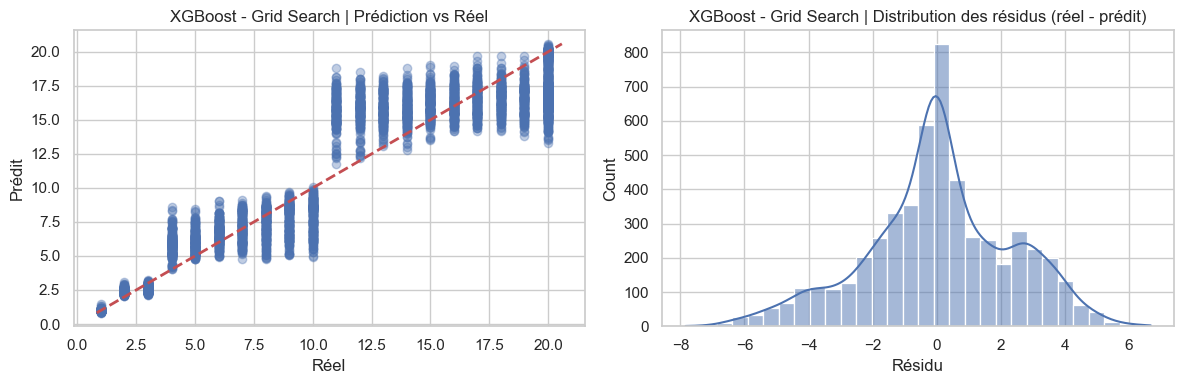


[XGBoost] Random Search
Meilleurs hyperparamètres :


model__colsample_bytree      0.70
model__learning_rate         0.03
model__max_depth             6.00
model__min_child_weight      2.00
model__n_estimators        800.00
model__reg_alpha             0.00
model__reg_lambda            1.00
model__subsample             0.95
dtype: float64

Métriques (test) : {'MAE': 1.7512968534588949, 'RMSE': 2.31215257397042, 'R2': 0.8660588522235481}


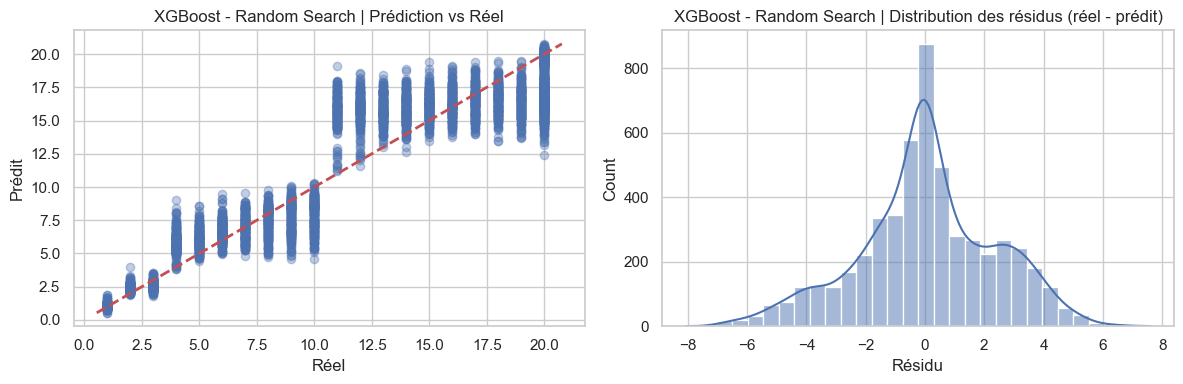

In [13]:
model_name = "XGBoost"
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
 )
pipe_xgb = make_pipeline(xgb)

param_grid_xgb = {
    "model__n_estimators": [300, 600],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.03, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}

gs_xgb = grid_search_classif(pipe_xgb, param_grid_xgb, X_train, y_train, cv=cv, verbose=0)
metrics_gs = run_search_and_evaluate(model_name, "Grid Search", gs_xgb, X_test, y_test)
add_result(model_name, "Grid", gs_xgb, metrics_gs)

param_dist_xgb = {
    "model__n_estimators": [200, 300, 400, 600, 800],
    "model__max_depth": [2, 3, 4, 5, 6, 7, 8],
    "model__learning_rate": np.linspace(0.01, 0.3, 30).tolist(),
    "model__subsample": np.linspace(0.6, 1.0, 9).tolist(),
    "model__colsample_bytree": np.linspace(0.6, 1.0, 9).tolist(),
    "model__min_child_weight": [1, 2, 5, 10],
    "model__reg_alpha": [0.0, 0.01, 0.1, 1.0],
    "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],
}

rs_xgb = random_search_classif(pipe_xgb, param_dist_xgb, X_train, y_train, cv=cv, n_iter=35, verbose=0)
metrics_rs = run_search_and_evaluate(model_name, "Random Search", rs_xgb, X_test, y_test)
add_result(model_name, "Random", rs_xgb, metrics_rs)

In [ ]:
#Simple Linear Regression


SIMPLE LINEAR REGRESSION

📊 Résultats - Simple Linear Regression (X = 'grid')
   Équation: finish_position = 0.2403 × grid + 9.3305
   MAE: 5.3032
   RMSE: 6.0738
   R²: 0.0757


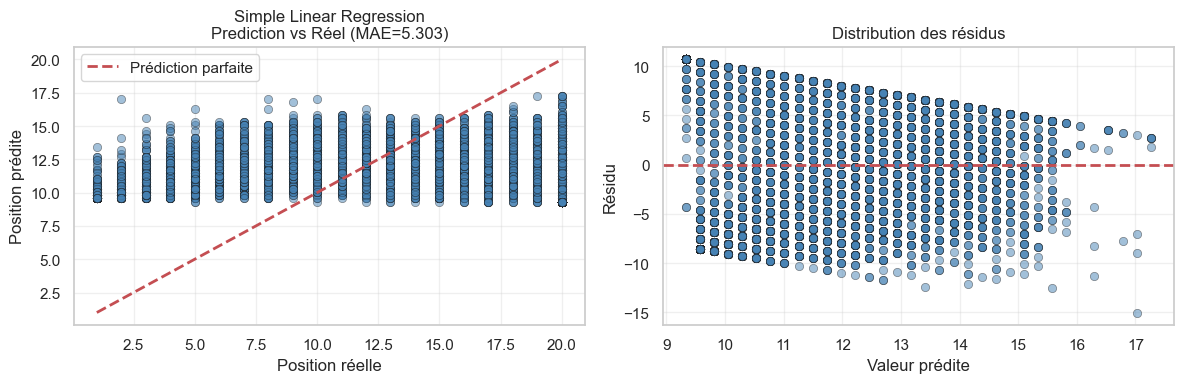

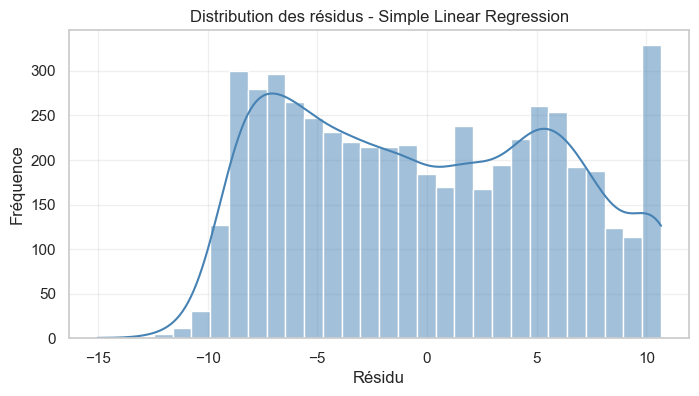

In [17]:
# =====================================================
# SIMPLE LINEAR REGRESSION - avec la variable 'grid' uniquement
# =====================================================

print("\n" + "="*60)
print("SIMPLE LINEAR REGRESSION")
print("="*60)

from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

# Pour la régression linéaire simple, on utilise une seule variable explicative
# 'grid' (position sur la grille) est le meilleur prédicteur individuel
feature_simple = 'grid'
X_simple_train = X_train[[feature_simple]]
X_simple_test = X_test[[feature_simple]]

# Gérer les valeurs manquantes
imputer = SimpleImputer(strategy='median')
X_simple_train = imputer.fit_transform(X_simple_train)
X_simple_test = imputer.transform(X_simple_test)

# Créer et entraîner le modèle
lr_simple = LinearRegression()
lr_simple.fit(X_simple_train, y_train)

# Prédictions
y_pred_simple = lr_simple.predict(X_simple_test)

# Métriques
mae_simple = mean_absolute_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))
r2_simple = r2_score(y_test, y_pred_simple)

print(f"\n📊 Résultats - Simple Linear Regression (X = '{feature_simple}')")
print(f"   Équation: finish_position = {lr_simple.coef_[0]:.4f} × grid + {lr_simple.intercept_:.4f}")
print(f"   MAE: {mae_simple:.4f}")
print(f"   RMSE: {rmse_simple:.4f}")
print(f"   R²: {r2_simple:.4f}")

# Graphiques
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Prédiction vs Réel
axes[0].scatter(y_test, y_pred_simple, alpha=0.5, color='steelblue', edgecolors='k', linewidth=0.5)
min_val = min(y_test.min(), y_pred_simple.min())
max_val = max(y_test.max(), y_pred_simple.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Prédiction parfaite')
axes[0].set_xlabel('Position réelle')
axes[0].set_ylabel('Position prédite')
axes[0].set_title(f'Simple Linear Regression\nPrediction vs Réel (MAE={mae_simple:.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Résidus
residuals = y_test - y_pred_simple
axes[1].scatter(y_pred_simple, residuals, alpha=0.5, color='steelblue', edgecolors='k', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Valeur prédite')
axes[1].set_ylabel('Résidu')
axes[1].set_title('Distribution des résidus')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Distribution des résidus
plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=30, kde=True, color='steelblue')
plt.xlabel('Résidu')
plt.ylabel('Fréquence')
plt.title(f'Distribution des résidus - Simple Linear Regression')
plt.grid(True, alpha=0.3)
plt.show()

# Ajouter aux résultats (en créant un objet factice avec les attributs attendus)
class DummySearch:
    def __init__(self, params):
        self.best_params_ = params
        self.best_score_ = np.nan  # Pas de cross-validation pour ce modèle simple

dummy_search = DummySearch({
    'feature': feature_simple,
    'coef': lr_simple.coef_[0],
    'intercept': lr_simple.intercept_
})

add_result("SimpleLinear", "Simple", dummy_search, 
           {"MAE": mae_simple, "RMSE": rmse_simple, "R2": r2_simple})

In [ ]:
#Multiple Linear Regression :


MULTIPLE LINEAR REGRESSION

📊 Résultats - Multiple Linear Regression
   MAE: 2.4448
   RMSE: 2.9302
   R²: 0.7849


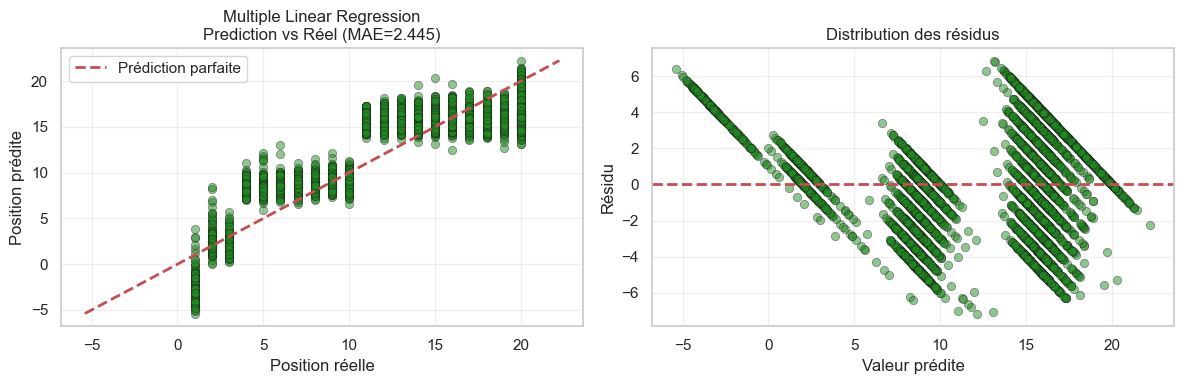

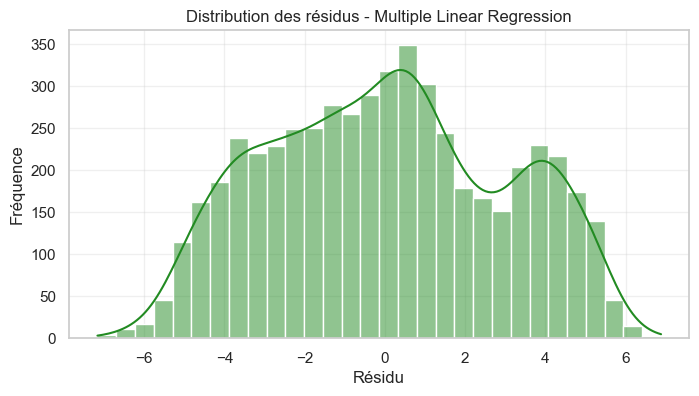


📊 Top 15 variables par importance (coefficients) :
                 feature  coefficient
  position_class_encoded     5.243286
     country_Switzerland    -1.026243
     driver_standing_pos     0.886844
                    grid    -0.623570
         driver_wins_cum     0.596235
constructor_standing_pos     0.561054
    country_South Africa     0.474292
          country_Sweden     0.414079
  constructor_points_cum    -0.385021
    country_Saudi Arabia    -0.341930
           country_Korea     0.332502
      country_Azerbaijan    -0.328627
    constructor_wins_cum     0.290187
         country_Bahrain    -0.282069
          country_Russia    -0.246234


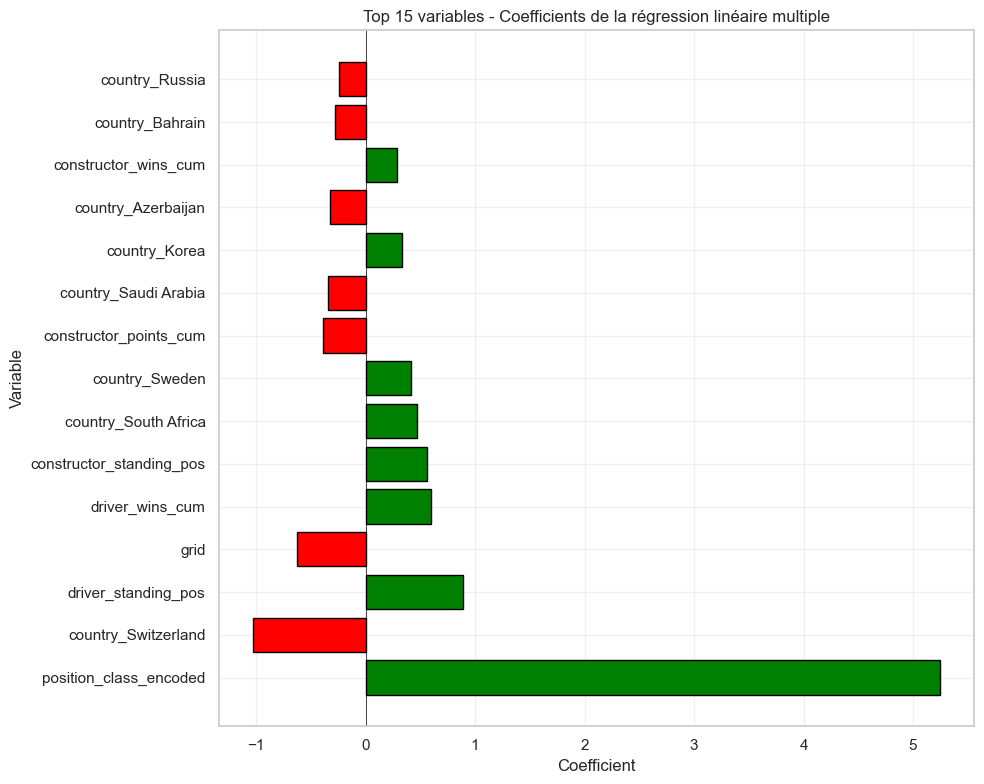

In [18]:
# =====================================================
# MULTIPLE LINEAR REGRESSION
# =====================================================

print("\n" + "="*60)
print("MULTIPLE LINEAR REGRESSION")
print("="*60)

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# Réutiliser le prétraitement déjà défini
lr_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LinearRegression())
])

# Entraînement
lr_multiple = lr_pipeline.fit(X_train, y_train)

# Prédictions
y_pred_lr = lr_multiple.predict(X_test)

# Métriques
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"\n📊 Résultats - Multiple Linear Regression")
print(f"   MAE: {mae_lr:.4f}")
print(f"   RMSE: {rmse_lr:.4f}")
print(f"   R²: {r2_lr:.4f}")

# Graphiques diagnostiques
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Prédiction vs Réel
axes[0].scatter(y_test, y_pred_lr, alpha=0.5, color='forestgreen', edgecolors='k', linewidth=0.5)
min_val = min(y_test.min(), y_pred_lr.min())
max_val = max(y_test.max(), y_pred_lr.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Prédiction parfaite')
axes[0].set_xlabel('Position réelle')
axes[0].set_ylabel('Position prédite')
axes[0].set_title(f'Multiple Linear Regression\nPrediction vs Réel (MAE={mae_lr:.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Résidus
residuals_lr = y_test - y_pred_lr
axes[1].scatter(y_pred_lr, residuals_lr, alpha=0.5, color='forestgreen', edgecolors='k', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Valeur prédite')
axes[1].set_ylabel('Résidu')
axes[1].set_title('Distribution des résidus')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Distribution des résidus
plt.figure(figsize=(8, 4))
sns.histplot(residuals_lr, bins=30, kde=True, color='forestgreen')
plt.xlabel('Résidu')
plt.ylabel('Fréquence')
plt.title(f'Distribution des résidus - Multiple Linear Regression')
plt.grid(True, alpha=0.3)
plt.show()

# Importance des variables (coefficients)
print("\n📊 Top 15 variables par importance (coefficients) :")

# Extraire le modèle et les noms des features
lr_model = lr_multiple.named_steps['model']
preprocessor = lr_multiple.named_steps['preprocess']

# Obtenir les noms des features après transformation
feature_names = []

# Variables numériques
if len(num_cols) > 0:
    feature_names.extend(num_cols)

# Variables catégorielles (one-hot encodées)
if len(cat_cols) > 0:
    ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
    for cat_col in cat_cols:
        categories = ohe.categories_[cat_cols.index(cat_col)]
        feature_names.extend([f"{cat_col}_{cat}" for cat in categories])

# Créer DataFrame des coefficients
coefficients = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lr_model.coef_
})
coefficients = coefficients.sort_values('coefficient', key=abs, ascending=False)

# Afficher top 15
print(coefficients.head(15).to_string(index=False))

# Graphique des coefficients
plt.figure(figsize=(10, 8))
top_coef = coefficients.head(15)
colors = ['red' if x < 0 else 'green' for x in top_coef['coefficient']]
plt.barh(top_coef['feature'], top_coef['coefficient'], color=colors, edgecolor='black')
plt.xlabel('Coefficient')
plt.ylabel('Variable')
plt.title('Top 15 variables - Coefficients de la régression linéaire multiple')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Ajouter aux résultats (créer un objet factice avec les attributs attendus)
class DummySearch:
    def __init__(self, params):
        self.best_params_ = params
        self.best_score_ = np.nan

dummy_search_lr = DummySearch({
    'model': 'MultipleLinearRegression',
    'intercept': lr_model.intercept_
})

add_result("MultipleLinear", "Linear", dummy_search_lr, 
           {"MAE": mae_lr, "RMSE": rmse_lr, "R2": r2_lr})

## Comparaison finale des modèles
On compare les modèles sur les métriques test (MAE, RMSE, R2).

,modele,methode,best_params,cv_best_score_neg_mae,test_mae,test_rmse,test_r2,fit_time_sec
0,XGBoost,Grid,"{'model__colsample_bytree': 1.0, 'model__learn...",-1.723044,1.722689,2.282263,0.869499,1.165051
1,DecisionTree,Random,"{'model__min_samples_split': 21, 'model__min_s...",-1.755444,1.736975,2.334182,0.863494,0.153043
2,DecisionTree,Grid,"{'model__max_depth': 12, 'model__max_features'...",-1.763324,1.748847,2.370355,0.859231,0.195644
3,XGBoost,Random,"{'model__subsample': 0.95, 'model__reg_lambda'...",-1.745920,1.751297,2.312153,0.866059,1.826426
4,SVR,Grid,"{'model__C': 10, 'model__epsilon': 0.05, 'mode...",-1.849050,1.835407,2.436276,0.851292,86.768018
5,SVR,Random,"{'model__kernel': 'rbf', 'model__gamma': 'scal...",-1.866689,1.852368,2.433566,0.851623,47.230787
6,RandomForest,Grid,"{'model__max_depth': None, 'model__max_feature...",-1.866862,1.873453,2.414511,0.853937,4.847597
7,RandomForest,Random,"{'model__n_estimators': 800, 'model__min_sampl...",-1.884616,1.874771,2.383351,0.857683,7.893646
8,KNN,Grid,"{'model__n_neighbors': 7, 'model__p': 2, 'mode...",-2.006695,2.003053,2.660842,0.822614,0.039284
9,KNN,Random,"{'model__weights': 'distance', 'model__p': 2, ...",-2.025511,2.006425,2.629693,0.826743,0.037606


,modele,methode,best_params,cv_best_score_neg_mae,test_mae,test_rmse,test_r2,fit_time_sec
0,XGBoost,Grid,"{'model__colsample_bytree': 1.0, 'model__learn...",-1.723044,1.722689,2.282263,0.869499,1.165051
1,DecisionTree,Random,"{'model__min_samples_split': 21, 'model__min_s...",-1.755444,1.736975,2.334182,0.863494,0.153043
2,SVR,Grid,"{'model__C': 10, 'model__epsilon': 0.05, 'mode...",-1.849050,1.835407,2.436276,0.851292,86.768018
3,RandomForest,Grid,"{'model__max_depth': None, 'model__max_feature...",-1.866862,1.873453,2.414511,0.853937,4.847597
4,KNN,Grid,"{'model__n_neighbors': 7, 'model__p': 2, 'mode...",-2.006695,2.003053,2.660842,0.822614,0.039284
5,MultipleLinear,Linear,"{'model': 'MultipleLinearRegression', 'interce...",NaN,2.444811,2.930231,0.784878,NaN
6,SimpleLinear,Simple,"{'feature': 'grid', 'coef': 0.2403297201311146...",NaN,5.303165,6.073781,0.075729,NaN


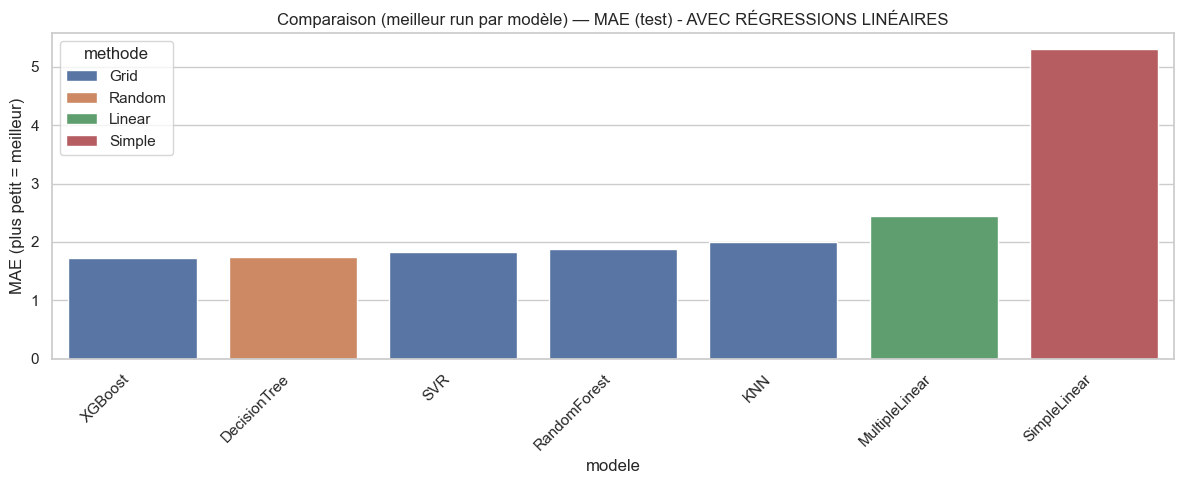

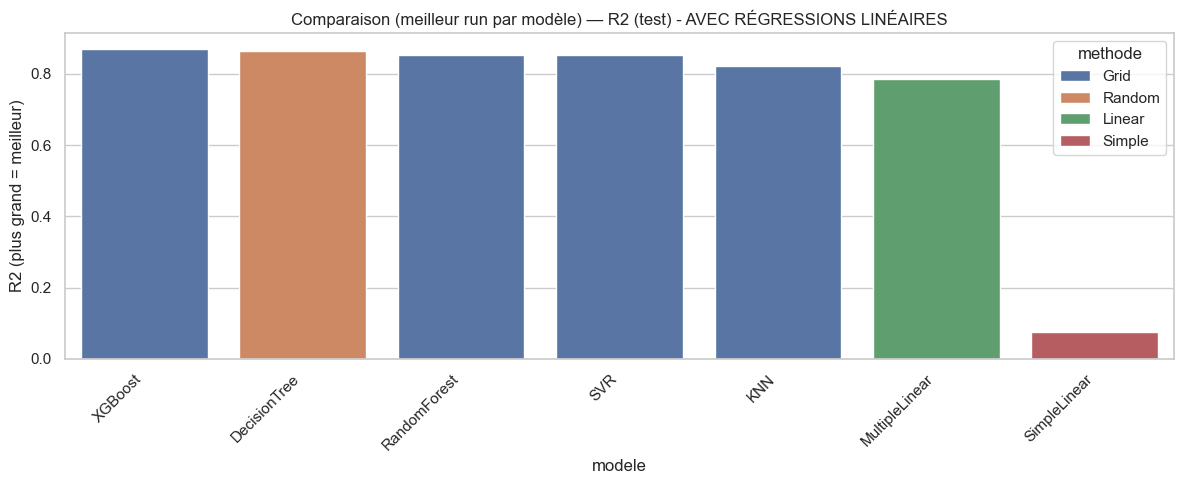


🏆 MEILLEUR RUN GLOBAL (MAE min) 🏆


modele                                                             XGBoost
methode                                                               Grid
best_params              {'model__colsample_bytree': 1.0, 'model__learn...
cv_best_score_neg_mae                                            -1.723044
test_mae                                                          1.722689
test_rmse                                                         2.282263
test_r2                                                           0.869499
fit_time_sec                                                      1.165051
Name: 8, dtype: object


📌 Meilleurs hyperparamètres :


model__colsample_bytree      1.00
model__learning_rate         0.03
model__max_depth             7.00
model__n_estimators        300.00
model__subsample             0.80
dtype: float64


📊 CLASSEMENT FINAL DES MODÈLES (par MAE)
        modele methode  test_mae  test_r2
       XGBoost    Grid  1.722689 0.869499
  DecisionTree  Random  1.736975 0.863494
  DecisionTree    Grid  1.748847 0.859231
       XGBoost  Random  1.751297 0.866059
           SVR    Grid  1.835407 0.851292
           SVR  Random  1.852368 0.851623
  RandomForest    Grid  1.873453 0.853937
  RandomForest  Random  1.874771 0.857683
           KNN    Grid  2.003053 0.822614
           KNN  Random  2.006425 0.826743
MultipleLinear  Linear  2.444811 0.784878
  SimpleLinear  Simple  5.303165 0.075729

📈 ANALYSE DES RÉSULTATS

✅ Meilleur modèle : XGBoost (Grid)
   - MAE: 1.7227
   - RMSE: 2.2823
   - R²: 0.8695

📊 Performance des régressions linéaires :
   - SimpleLinear: MAE=5.3032, R²=0.0757
   - MultipleLinear: MAE=2.4448, R²=0.7849

🚀 Amélioration du meilleur modèle complexe (XGBoost) par rapport à la meilleure régression linéaire :
   - Gain sur MAE: 29.5%


In [19]:
# =====================================================
# COMPARAISON FINALE DES MODÈLES (avec régressions linéaires)
# =====================================================

results_df = pd.DataFrame(results)
display(results_df.sort_values(["test_mae"]).reset_index(drop=True))
  
# Résumé : meilleur run par modèle (MAE minimal sur test)
best_by_model = (
    results_df.sort_values("test_mae")
    .groupby("modele", as_index=False)
    .first()
)
display(best_by_model.sort_values("test_mae").reset_index(drop=True))

# Graphique MAE
plt.figure(figsize=(12, 5))
sns.barplot(data=best_by_model.sort_values("test_mae"), x="modele", y="test_mae", hue="methode")
plt.title("Comparaison (meilleur run par modèle) — MAE (test) - AVEC RÉGRESSIONS LINÉAIRES")
plt.ylabel("MAE (plus petit = meilleur)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Graphique R2
plt.figure(figsize=(12, 5))
sns.barplot(data=best_by_model.sort_values("test_r2", ascending=False), x="modele", y="test_r2", hue="methode")
plt.title("Comparaison (meilleur run par modèle) — R2 (test) - AVEC RÉGRESSIONS LINÉAIRES")
plt.ylabel("R2 (plus grand = meilleur)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Afficher les meilleurs hyperparamètres du meilleur run global
best_global = results_df.sort_values("test_mae").iloc[0]
print("\n" + "="*60)
print("🏆 MEILLEUR RUN GLOBAL (MAE min) 🏆")
print("="*60)
display(best_global)

# Afficher les paramètres du meilleur modèle
print("\n📌 Meilleurs hyperparamètres :")
if isinstance(best_global["best_params"], dict):
    display(pd.Series(best_global["best_params"]).sort_index())
else:
    print(best_global["best_params"])

# Classement final
print("\n" + "="*60)
print("📊 CLASSEMENT FINAL DES MODÈLES (par MAE)")
print("="*60)
ranking = results_df.sort_values("test_mae")[["modele", "methode", "test_mae", "test_r2"]]
print(ranking.to_string(index=False))

# Analyse des résultats
print("\n" + "="*60)
print("📈 ANALYSE DES RÉSULTATS")
print("="*60)

# Meilleur modèle
best_model = results_df.loc[results_df['test_mae'].idxmin()]
print(f"\n✅ Meilleur modèle : {best_model['modele']} ({best_model['methode']})")
print(f"   - MAE: {best_model['test_mae']:.4f}")
print(f"   - RMSE: {best_model['test_rmse']:.4f}")
print(f"   - R²: {best_model['test_r2']:.4f}")

# Performance des régressions linéaires
lr_models = results_df[results_df['modele'].isin(['SimpleLinear', 'MultipleLinear'])]
if not lr_models.empty:
    print("\n📊 Performance des régressions linéaires :")
    for _, row in lr_models.iterrows():
        print(f"   - {row['modele']}: MAE={row['test_mae']:.4f}, R²={row['test_r2']:.4f}")

# Comparaison avec les modèles complexes
complex_models = results_df[~results_df['modele'].isin(['SimpleLinear', 'MultipleLinear'])]
if not complex_models.empty:
    best_complex = complex_models.loc[complex_models['test_mae'].idxmin()]
    improvement = (lr_models['test_mae'].min() - best_complex['test_mae']) / lr_models['test_mae'].min() * 100
    print(f"\n🚀 Amélioration du meilleur modèle complexe ({best_complex['modele']}) par rapport à la meilleure régression linéaire :")
    print(f"   - Gain sur MAE: {improvement:.1f}%")